# Hyperparameter Tuning for Lead Scoring Model

## Objective
This notebook tunes the selected XGBoost model to improve lead scoring performance while preserving a realistic pre-contact setup.

## Tuning Strategy
We use:
- a clean preprocessing pipeline
- `RandomizedSearchCV` for efficient hyperparameter exploration
- `roc_auc` as the main optimization metric
- a held-out test set for final evaluation

## Modeling Principle
The goal is not only to improve raw performance, but to keep the model robust and useful for business prioritization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("/Users/omarpiro/ML_DL_Projects/AI_LEAD_SCORE/data/raw/bank+marketing/bank/bank-full.csv", sep=";")
df['target'] = df['y'].map({'no': 0, 'yes': 1})
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


## Feature Selection Principle

The feature `duration` is excluded from tuning and final modeling.

Although it is highly predictive, it is only known after the interaction has occurred. Including it in a pre-contact lead scoring system would introduce data leakage.


In [3]:
drop_cols = ["y", "target", "duration"]

X = df.drop(columns=drop_cols)
y = df["target"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

ordinal_cols = ["education"]
ordinal_categories = [["unknown", "primary", "secondary", "tertiary"]]
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)
print("Ordinal columns:", ordinal_cols)
print("Nominal columns:", nominal_cols)


Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical features: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Ordinal columns: ['education']
Nominal columns: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (36168, 15)
Test shape: (9043, 15)


In [5]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=ordinal_categories))
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("ord", ordinal_transformer, ordinal_cols),
        ("nom", nominal_transformer, nominal_cols)
    ]
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

## Baseline Tuning Candidate

We tune XGBoost because it provided the best overall balance between ranking quality and recall in the previous notebook.


In [6]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    ))
])

xgb_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

## Hyperparameter Search Space

The search space is intentionally moderate:
- large enough to explore meaningful configurations
- small enough to remain practical on a local machine


In [7]:
param_distributions = {
    "classifier__n_estimators": [100, 150, 200, 300],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5, 7],
    "classifier__gamma": [0, 0.1, 0.3, 0.5],
    "classifier__reg_alpha": [0, 0.01, 0.1, 1],
    "classifier__reg_lambda": [1, 1.5, 2, 3]
}


In [8]:
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__gamma': [0, 0.1, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscro

In [9]:
print("Best ROC-AUC (CV):", round(random_search.best_score_, 4))
print("Best Parameters:")
random_search.best_params_


Best ROC-AUC (CV): 0.7961
Best Parameters:


{'classifier__subsample': 0.9,
 'classifier__reg_lambda': 1,
 'classifier__reg_alpha': 0,
 'classifier__n_estimators': 200,
 'classifier__min_child_weight': 1,
 'classifier__max_depth': 3,
 'classifier__learning_rate': 0.1,
 'classifier__gamma': 0.1,
 'classifier__colsample_bytree': 0.7}

## Best Model

The selected model is the configuration that achieved the best average ROC-AUC across cross-validation folds.


In [10]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


In [11]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

pd.DataFrame([final_metrics]).round(4)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.8138,0.3424,0.6427,0.4468,0.8027


In [12]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.84      0.89      7985
           1       0.34      0.64      0.45      1058

    accuracy                           0.81      9043
   macro avg       0.64      0.74      0.67      9043
weighted avg       0.88      0.81      0.84      9043



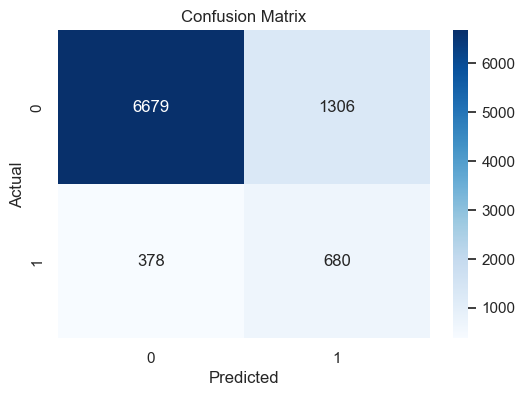

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


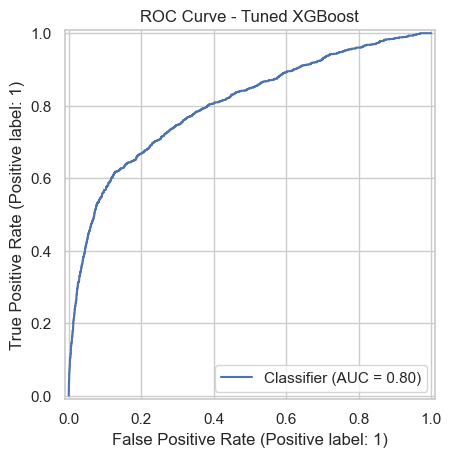

In [14]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Tuned XGBoost")
plt.show()


## Business-Oriented Evaluation

Classification metrics are useful, but this remains a lead prioritization problem.

We therefore evaluate how well the tuned model concentrates conversions in the highest-ranked leads.


In [15]:
results_analysis = pd.DataFrame({
    "y_true": y_test,
    "score": y_proba
}).sort_values(by="score", ascending=False)

results_analysis.head()


,y_true,score
43122,1,0.987983
45126,1,0.984567
43135,0,0.983554
43165,0,0.982983
43164,1,0.981732


In [16]:
def precision_at_k(df, k):
    top_k = int(len(df) * k)
    return df.iloc[:top_k]["y_true"].mean()

business_metrics = []
baseline_rate = y_test.mean()

for k in [0.1, 0.2, 0.3, 0.5]:
    p_at_k = precision_at_k(results_analysis, k)
    business_metrics.append({
        "Top Segment": f"Top {int(k*100)}%",
        "Precision@K": round(p_at_k, 4),
        "Baseline Rate": round(baseline_rate, 4),
        "Uplift": round(p_at_k / baseline_rate, 2)
    })

business_metrics_df = pd.DataFrame(business_metrics)
business_metrics_df


,Top Segment,Precision@K,Baseline Rate,Uplift
0,Top 10%,0.5210,0.117,4.45
1,Top 20%,0.3667,0.117,3.13
2,Top 30%,0.2747,0.117,2.35
3,Top 50%,0.1946,0.117,1.66


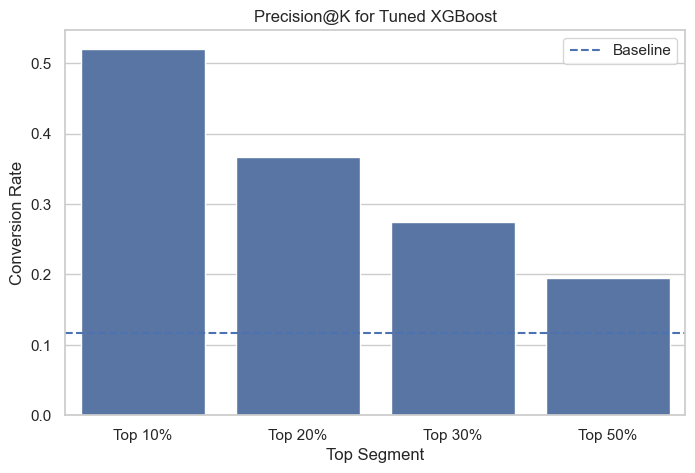

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=business_metrics_df, x="Top Segment", y="Precision@K")
plt.axhline(baseline_rate, linestyle="--", label="Baseline")
plt.title("Precision@K for Tuned XGBoost")
plt.ylabel("Conversion Rate")
plt.legend()
plt.show()


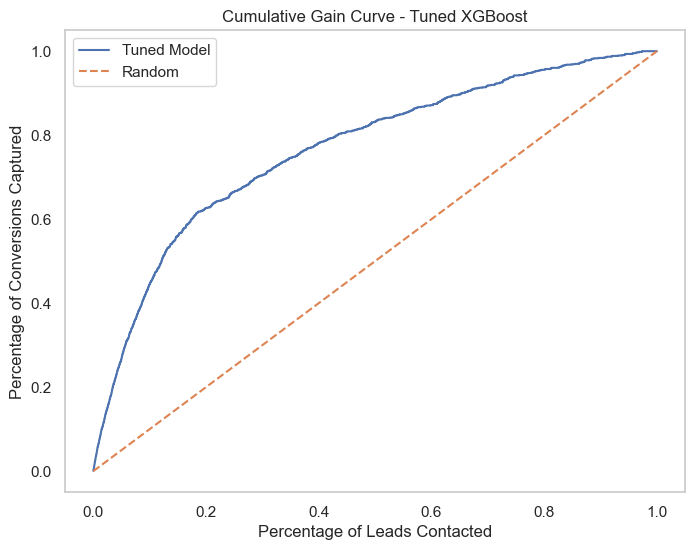

In [18]:
df_gain = results_analysis.copy()
total_positives = df_gain["y_true"].sum()

df_gain["cum_conversions"] = df_gain["y_true"].cumsum()
df_gain["perc_leads"] = np.arange(1, len(df_gain) + 1) / len(df_gain)
df_gain["perc_conversions"] = df_gain["cum_conversions"] / total_positives

plt.figure(figsize=(8, 6))
plt.plot(df_gain["perc_leads"], df_gain["perc_conversions"], label="Tuned Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("Percentage of Leads Contacted")
plt.ylabel("Percentage of Conversions Captured")
plt.title("Cumulative Gain Curve - Tuned XGBoost")
plt.legend()
plt.grid()
plt.show()


## Final Conclusion

This notebook tunes the selected XGBoost model using cross-validated random search.

### What was improved
- a structured hyperparameter search
- selection based on ROC-AUC
- final evaluation on a held-out test set
- business-oriented lead prioritization analysis

### Practical Outcome
The tuned model can now serve as a stronger candidate for:
- model export
- batch scoring
- API deployment
- production-oriented lead prioritization workflows


In [19]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/tuned_xgb_pipeline.joblib")
print("Model pipeline saved successfully.")

Model pipeline saved successfully.
